In [1]:
import os

os.chdir('..')

In [2]:
import os
import json
from collections import defaultdict
from nltk.translate.bleu_score import sentence_bleu
from rouge import Rouge
import numpy as np
import pandas as pd



def calculate_bleu(references, candidates):
    scores = [sentence_bleu([ref.split()], cand.split()) for ref, cand in zip(references, candidates)]
    return np.round(np.mean(scores) * 100, 1) if scores else 0

# Function to calculate ROUGE score
def calculate_rouge(references, candidates):
    rouge = Rouge()
    scores = rouge.get_scores(candidates, references, avg=True)
    rouge_1 = np.round(scores['rouge-1']['f'] * 100, 1)
    rouge_2 = np.round(scores['rouge-2']['f'] * 100, 1)
    rouge_l = np.round(scores['rouge-l']['f'] * 100, 1)
    return (rouge_1+rouge_2+rouge_l)/3

# Function to calculate Exact Match score
def calculate_em(references, candidates):
    references = [ref.split("\n\n")[0] for ref in references]
    em_scores = [1 if cal_correct(ref, cand) else 0 for ref, cand in zip(references, candidates)]
    return np.round(np.mean(em_scores) * 100, 1) if em_scores else 0

def cal_correct(generated_answer, expected_answer):
    is_correct = generated_answer.strip().lower().replace(".", "") == expected_answer.strip().lower().replace(".", "")
    return is_correct

In [3]:
import sys

import torch
from transformers import LlamaForCausalLM, LlamaTokenizer
from tqdm import tqdm
from peft import PeftModel
import json
import numpy as np
from datasets import load_dataset
from utils.prompter import Prompter
import torch
import torch.nn as nn
import torch.nn.functional as F

model_outputs_folder = "./performance_large/outputs/"
config_path = "./config/config2.json"
with open(config_path, 'r') as file:
    lora_configs = json.load(file)

model_names = []
for config in lora_configs:
    model_names.append(config['model_name'])

model_output_dicts_val = {}

for file_name in os.listdir(model_outputs_folder):
    if file_name == '.DS_Store':
        continue

    if file_name.startswith("model_test") or file_name.startswith("degraded_model"):
        continue

    model_index = int(file_name.split('_')[-1].split('.')[0])
    model_index = model_names[model_index]
    model_output_dicts_val[model_index] = {}

    with open(os.path.join(model_outputs_folder, file_name), 'r', encoding='utf-8') as f:
        json_data = json.load(f)

        for sample in json_data:
            metric = sample['metric']
            if metric == 'bleu':
                model_output_dicts_val[model_index][sample['inputs']] = calculate_bleu([sample['targets']], [sample['predicted_answer']])
            if metric == 'rouge':
                model_output_dicts_val[model_index][sample['inputs']] = calculate_rouge([sample['targets']], [sample['predicted_answer']])
            if metric == 'em':
                model_output_dicts_val[model_index][sample['inputs']] = calculate_em([sample['targets']], [sample['predicted_answer']])

/Users/igor/.local/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/igor/.local/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/igor/.local/lib/python3.10/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunc

In [4]:
import sys

import torch
from transformers import LlamaForCausalLM, LlamaTokenizer
from tqdm import tqdm
from peft import PeftModel
import json
import numpy as np
from datasets import load_dataset
from utils.prompter import Prompter
import torch
import torch.nn as nn
import torch.nn.functional as F

model_outputs_folder = "./performance_large/outputs/"
config_path = "./config/config2.json"
with open(config_path, 'r') as file:
    lora_configs = json.load(file)

model_names = []
for config in lora_configs:
    model_names.append(config['model_name'])

model_output_dicts_test = {}

for file_name in os.listdir(model_outputs_folder):
    if not file_name.startswith("model_test"):
        continue

    model_index = int(file_name.split('_')[-1].split('.')[0])
    model_index = model_names[model_index]
    model_output_dicts_test[model_index] = {}

    with open(os.path.join(model_outputs_folder, file_name), 'r', encoding='utf-8') as f:
        json_data = json.load(f)

        for sample in json_data:
            metric = sample['metric']
            if metric == 'bleu':
                model_output_dicts_test[model_index][sample['inputs']] = calculate_bleu([sample['targets']], [sample['predicted_answer']])
            if metric == 'rouge':
                model_output_dicts_test[model_index][sample['inputs']] = calculate_rouge([sample['targets']], [sample['predicted_answer']])
            if metric == 'em':
                model_output_dicts_test[model_index][sample['inputs']] = calculate_em([sample['targets']], [sample['predicted_answer']])

In [5]:
data_path = "./dataset/config_large_flat.json"
if data_path.endswith(".json") or data_path.endswith(".jsonl"):
    dataset_val = load_dataset("json", data_files=data_path)
else:
    dataset_val = load_dataset(data_path)

dataset_val = dataset_val['train']

data_path = './dataset/combined_test.json'
data_path = "./dataset/combined_test.json"
if data_path.endswith(".json") or data_path.endswith(".jsonl"):
    dataset_test = load_dataset("json", data_files=data_path)
else:
    dataset_test = load_dataset(data_path)

dataset_test = dataset_test['train']

In [6]:
max_score_per_sample = {}
for sample in dataset_val:
    max_score_per_sample[sample['inputs']] = -1.0
    for i in range(48):
        model_index = model_names[i]
        max_score_per_sample[sample['inputs']] = max(max_score_per_sample[sample['inputs']], model_output_dicts_val[model_index][sample['inputs']])

In [7]:
# Load embeddings
validation_embeddings = np.load('test_results/validation_embeddings.npy')
test_embeddings = np.load('test_results/test_embeddings.npy')

print(f"Validation embeddings shape: {validation_embeddings.shape}")
print(f"Test embeddings shape: {test_embeddings.shape}")

Validation embeddings shape: (8760, 768)
Test embeddings shape: (2395, 768)


In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

def cluster_embeddings_kmeans(embeddings, dataset_val, n_clusters, random_state=42):
    """
    Cluster embeddings using K-Means algorithm with cosine similarity.
    
    Parameters:
    -----------
    embeddings : np.ndarray
        Array of shape (n_samples, embedding_dim) containing the embeddings
    n_clusters : int
        The number of clusters to form
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    labels : np.ndarray
        Cluster labels for each sample (0 to n_clusters-1)
    n_clusters : int
        Number of clusters (same as input parameter)
    cluster_embeddings : np.ndarray
        Average embeddings for each cluster (shape: n_clusters x embedding_dim)
    """
    # Normalize embeddings for cosine similarity-based clustering
    normalized_embeddings = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-8)
    
    # Perform K-Means clustering with parallel processing
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    labels = kmeans.fit_predict(normalized_embeddings)
    
    # Compute cluster embeddings by averaging original embeddings in each cluster
    cluster_embeddings = np.zeros((n_clusters, embeddings.shape[1]))
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        if np.any(cluster_mask):
            cluster_embeddings[cluster_id] = embeddings[cluster_mask].mean(axis=0)

    model_performance = np.zeros((n_clusters, 48))
    for id, sample in enumerate(dataset_val):
        cluster_id = labels[id]
        if max_score_per_sample[sample['inputs']]==0.0:
            continue
        for i in range(48):
            model_index = model_names[i]
            model_performance[cluster_id][i] += model_output_dicts_val[model_index][sample['inputs']]/max_score_per_sample[sample['inputs']]
            
    return cluster_embeddings, model_performance

In [22]:
def evalute_clusters(k, dataset_val=dataset_val):
    cluster_embeddings, model_performance = cluster_embeddings_kmeans(validation_embeddings, dataset_val, k)
    results_by_domain = {}
    for id, sample in enumerate(dataset_test):
        domain = sample['domain']
        if domain not in results_by_domain:
            results_by_domain[domain] = []
        
        I = test_embeddings[id,:]
        I_norm = I / (np.linalg.norm(I) + 1e-8)  # Normalize input embedding
        A_norm = cluster_embeddings / (np.linalg.norm(cluster_embeddings, axis=1, keepdims=True) + 1e-8)  # Normalize cluster embeddings
        logits = I_norm @ A_norm.T  # Cosine similarity
        selected_task = logits.argmax()
        selected_model = model_performance[selected_task,:].argmax()
        model_index = model_names[selected_model]
        results_by_domain[domain].append(model_output_dicts_test[model_index][sample['inputs']])

    norm_by_domain = np.array([53., 68., 91., 67.7, 50.5, 63., 71., 64.5, 73.5, 13.2])
    total_score = 0.0

    for i, domain in enumerate(results_by_domain.keys()):
        results_by_domain[domain] = np.array(results_by_domain[domain]).mean()
        total_score += results_by_domain[domain]/norm_by_domain[i]/10
    
    return results_by_domain, total_score

In [23]:
results = []
for p in range(8):
    _, total_score = evalute_clusters(k=6*pow(2,p))
    results.append(total_score)
    print(f"K: {6*pow(2,p)} ", total_score)

K: 6  0.829825944877535
K: 12  0.8633043453692163
K: 12  0.8633043453692163
K: 24  0.8829397194355262
K: 24  0.8829397194355262
K: 48  0.9086020020184721
K: 48  0.9086020020184721
K: 96  0.9399618949771833
K: 96  0.9399618949771833
K: 192  0.9397332938739144
K: 192  0.9397332938739144
K: 384  0.9333113527406133
K: 384  0.9333113527406133
K: 768  0.9098237724704806
K: 768  0.9098237724704806


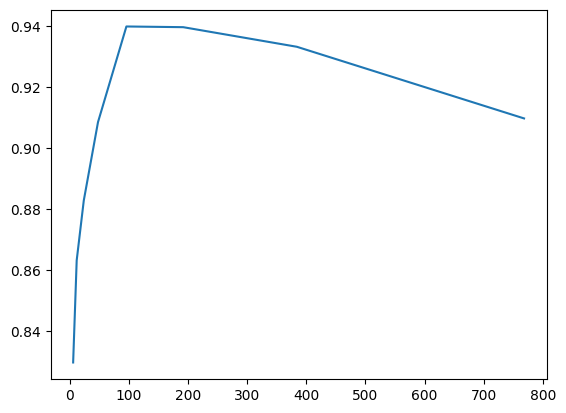

In [24]:
import matplotlib.pyplot as plt
plt.plot([6*pow(2,p) for p in range(8)], results)

In [13]:
def cluster_embeddings_kmeans_ood(embeddings, exclude_model, dataset_val, n_clusters=10):
    filtered_embeddings = []
    filtered_dataset = []
    for id, sample in enumerate(dataset_val):
        if sample['model_name'] == exclude_model:
            continue
        filtered_dataset.append(sample)
        filtered_embeddings.append(embeddings[id,:])
    filtered_embeddings = np.array(filtered_embeddings)
    
    return cluster_embeddings_kmeans(filtered_embeddings, filtered_dataset, n_clusters)

In [14]:
def evalute_clusters_ood(k=None, dataset_val=dataset_val):
    all_cluster_embeddings = []
    all_model_performance = []
    for id, model in enumerate(model_names):
        cluster_embeddings, model_performance = cluster_embeddings_kmeans_ood(validation_embeddings, model, dataset_val, k)
        model_performance[:,id] = -1.0
        all_cluster_embeddings.append(cluster_embeddings)
        all_model_performance.append(model_performance)
    
    results_by_domain = {}
    for id, sample in enumerate(dataset_test):
        domain = sample['domain']
        if domain not in results_by_domain:
            results_by_domain[domain] = []

        model_id = model_names.index(sample['task'])
        model_performance = all_model_performance[model_id]
        cluster_embeddings = all_cluster_embeddings[model_id]
        
        I = test_embeddings[id,:]
        I_norm = I / (np.linalg.norm(I) + 1e-8)  # Normalize input embedding
        A_norm = cluster_embeddings / (np.linalg.norm(cluster_embeddings, axis=1, keepdims=True) + 1e-8)  # Normalize cluster embeddings
        logits = I_norm @ A_norm.T  # Cosine similarity
        selected_task = logits.argmax()
        selected_model = model_performance[selected_task,:].argmax()
        model_index = model_names[selected_model]
        results_by_domain[domain].append(model_output_dicts_test[model_index][sample['inputs']])

    norm_by_domain = np.array([53., 68., 91., 67.7, 50.5, 63., 71., 64.5, 73.5, 13.2])
    total_score = 0.0

    for i, domain in enumerate(results_by_domain.keys()):
        results_by_domain[domain] = np.array(results_by_domain[domain]).mean()
        total_score += results_by_domain[domain]/norm_by_domain[i]/10
    
    return results_by_domain, total_score

In [15]:
results_ood = []
for p in range(8):
    _, total_score = evalute_clusters_ood(6*pow(2,p))
    results_ood.append(total_score)
    print(f"K: {6*pow(2,p)} ", results_ood[-1])

K: 6  0.7499111783379901
K: 12  0.8073340209819158
K: 12  0.8073340209819158
K: 24  0.7690168945680335
K: 24  0.7690168945680335
K: 48  0.7349371147358003
K: 48  0.7349371147358003
K: 96  0.7325982524469814
K: 96  0.7325982524469814
K: 192  0.7389636344468852
K: 192  0.7389636344468852
K: 384  0.6915479206343232
K: 384  0.6915479206343232
K: 768  0.6835596480003133
K: 768  0.6835596480003133


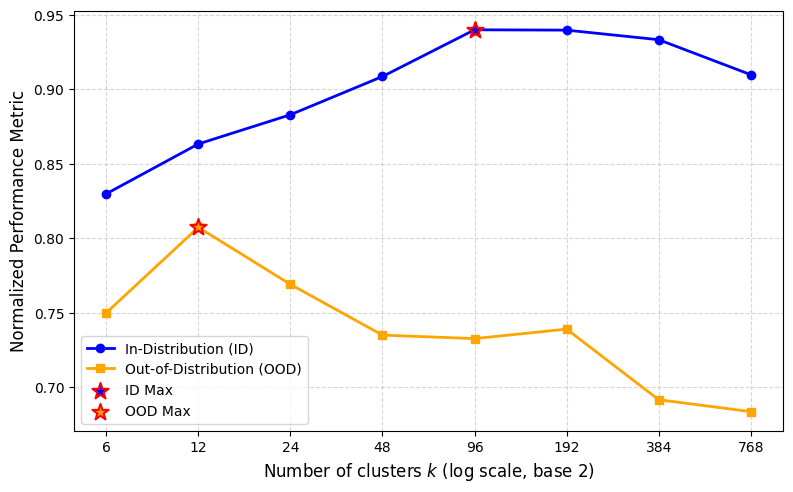

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'results' and 'results_ood' are defined (dummy data for example)
# x_values = [6*pow(2,p) for p in range(8)] -> [6, 12, 24, 48, 96, 192, 384, 768]
x_values = np.array([6*pow(2,p) for p in range(8)])

plt.figure(figsize=(8, 5)) # Set a standard figure size

# Plotting the data
plt.semilogx(x_values, results, marker='o', base=2, label="In-Distribution (ID)", color='blue', linewidth=2)
plt.semilogx(x_values, results_ood, marker='s', base=2, label="Out-of-Distribution (OOD)", color='orange', linewidth=2)

# --- Recommended Tick/Axis Improvements ---
# Set manual ticks for clarity on log scale (all values used)
plt.xticks(x_values, [str(k) for k in x_values])
plt.xlabel("Number of clusters $k$ (log scale, base 2)", fontsize=12)
plt.ylabel("Normalized Performance Metric", fontsize=12)
plt.yticks(fontsize=10) # Adjust tick label size
plt.xticks(fontsize=10)

# --- Current Highlighting Logic (Moved inside figure setup) ---
max_idx_results = np.argmax(results)
max_idx_results_ood = np.argmax(results_ood)

# Mark maximum points with larger, distinct markers (using markerfacecolor for contrast)
plt.scatter(x_values[max_idx_results], results[max_idx_results],
            s=150, marker='*', color='blue', edgecolor='red', linewidth=1.5, zorder=5, label='ID Max')
plt.scatter(x_values[max_idx_results_ood], results_ood[max_idx_results_ood],
            s=150, marker='*', color='orange', edgecolor='red', linewidth=1.5, zorder=5, label='OOD Max')

# Use a slightly stronger grid
plt.grid(True, linestyle='--', alpha=0.5, which='both')
# Better legend placement (handles all labels, including max points)
plt.legend(loc='lower left', frameon=True, fontsize=10)
plt.tight_layout()
plt.show()